## Series Temporales con datos de input


 SERIES TEMPORALES MULTIVARIANTES - Venta de Depósitos  
 Dataset: UCI Bank Marketing  
 Modelos: ARIMAX, VAR, LSTM con inputs exógenos  



#### 0. Importamos los datos

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

# Alternativa directa si tienes el archivo:
# df_raw = pd.read_csv("bank-additional-full.csv", sep=";")

# Para este ejemplo usamos la versión de 10% (más rápido)
import io, zipfile, urllib.request

print("Descargando dataset UCI Bank Marketing...")
with urllib.request.urlopen(url) as response:
    zip_data = io.BytesIO(response.read())

with zipfile.ZipFile(zip_data) as z:
    with z.open("bank-additional/bank-additional-full.csv") as f:
        df_raw = pd.read_csv(f, sep=";")

print(f"Shape original: {df_raw.shape}")
print(df_raw[['month','y','campaign','euribor3m','emp.var.rate']].head())

Descargando dataset UCI Bank Marketing...
Shape original: (41188, 21)
  month   y  campaign  euribor3m  emp.var.rate
0   may  no         1      4.857           1.1
1   may  no         1      4.857           1.1
2   may  no         1      4.857           1.1
3   may  no         1      4.857           1.1
4   may  no         1      4.857           1.1


In [8]:
df_raw

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,month_num,y_bin
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,11,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,11,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,11,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,11,1


#### 1. Construimos las series mensuales

In [3]:

# Mapeo de los meses → número para ordenar cronológicamente
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

df_raw['month_num'] = df_raw['month'].map(month_map)
df_raw['y_bin'] = (df_raw['y'] == 'yes').astype(int)

# Agrupamos por mes: depósitos vendidos, intensidad campaña, tipos interés
monthly = df_raw.groupby('month_num').agg(
    depositos_vendidos = ('y_bin', 'sum'),         # TARGET
    llamadas_marketing  = ('campaign', 'sum'),      # Input exógeno 1
    euribor3m           = ('euribor3m', 'mean'),    # Input exógeno 2
    emp_var_rate        = ('emp.var.rate', 'mean'), # Indice de variacion de la tasa de empleo. Macro: indicado de como evoluciona la economía
    cons_conf_idx       = ('cons.conf.idx', 'mean') # Indice de confianza del consumidor
).reset_index().sort_values('month_num')

# Crear fechas ficticias (los datos son 2008-2010, usamos año fijo para el ejemplo)
monthly['fecha'] = pd.date_range(start='2008-05-01', periods=len(monthly), freq='MS')
monthly.set_index('fecha', inplace=True)

print("\nSerie temporal mensual construida:")
print(monthly.to_string())


Serie temporal mensual construida:
            month_num  depositos_vendidos  llamadas_marketing  euribor3m  emp_var_rate  cons_conf_idx
fecha                                                                                                
2008-05-01          3                 276                1203   1.162745     -1.800000     -42.650549
2008-06-01          4                 539                5125   1.361070     -1.800000     -46.273632
2008-07-01          5                 886               33593   3.293665     -0.164972     -40.579272
2008-08-01          6                 559               16338   4.256908      0.688379     -41.579428
2008-09-01          7                 649               22677   4.685678      1.158921     -42.370170
2008-10-01          8                 655               16474   4.300623      0.747151     -35.597184
2008-11-01          9                 256                1011   0.834760     -2.177368     -33.893158
2008-12-01         10                 315     

#### 2. Visualizamos las series

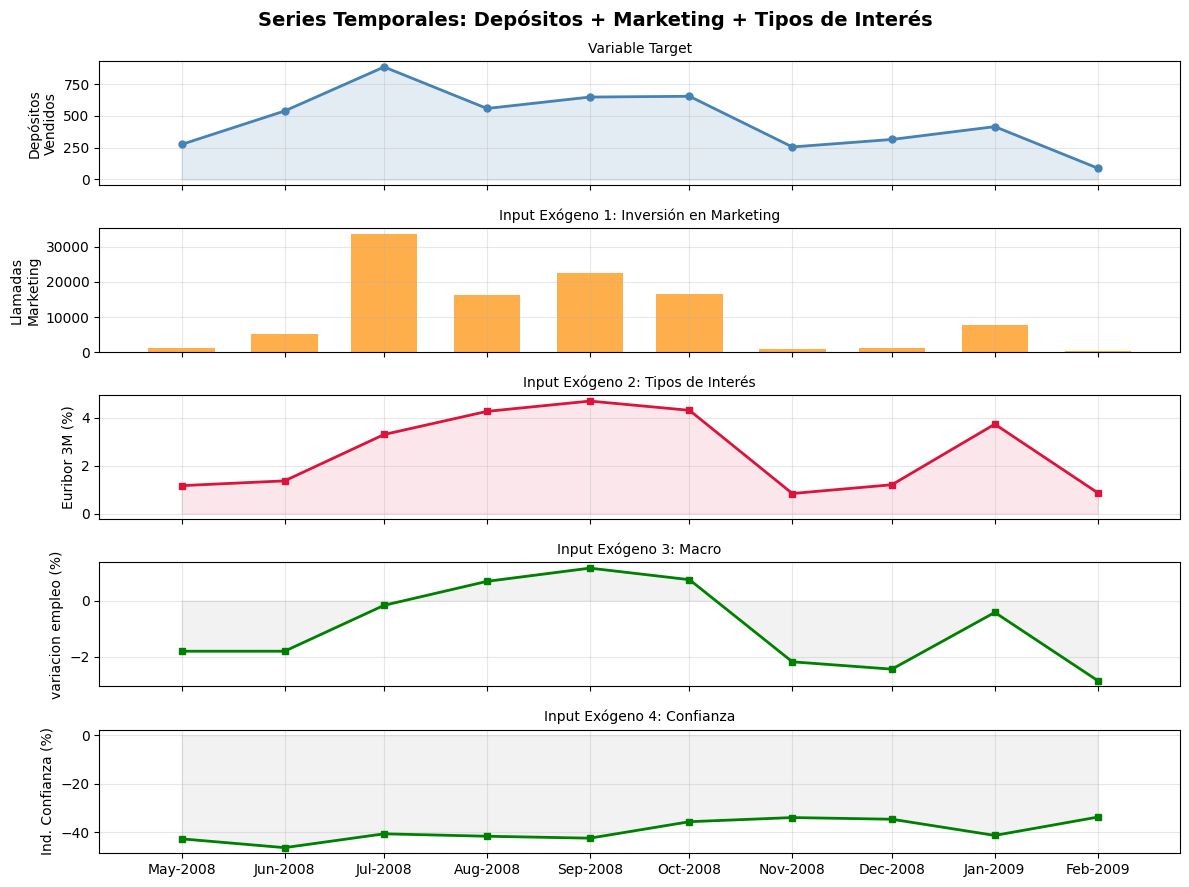

In [19]:

fig, axes = plt.subplots(5, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Series Temporales: Depósitos + Marketing + Tipos de Interés', 
             fontsize=14, fontweight='bold')

# Serie 1: Depósitos (TARGET)
axes[0].plot(monthly.index, monthly['depositos_vendidos'], 
             color='steelblue', linewidth=2, marker='o', markersize=5)
axes[0].fill_between(monthly.index, monthly['depositos_vendidos'], alpha=0.15, color='steelblue')
axes[0].set_ylabel('Depósitos\nVendidos', fontsize=10)
axes[0].set_title('Variable Target', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Serie 2: Marketing (INPUT EXÓGENO 1)
axes[1].bar(monthly.index, monthly['llamadas_marketing'], 
            color='darkorange', alpha=0.7, width=20)
axes[1].set_ylabel('Llamadas\nMarketing', fontsize=10)
axes[1].set_title('Input Exógeno 1: Inversión en Marketing', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Serie 3: Tipos de interés (INPUT EXÓGENO 2)
axes[2].plot(monthly.index, monthly['euribor3m'], 
             color='crimson', linewidth=2, marker='s', markersize=5)
axes[2].fill_between(monthly.index, monthly['euribor3m'], alpha=0.1, color='crimson')
axes[2].set_ylabel('Euribor 3M (%)', fontsize=10)
axes[2].set_title('Input Exógeno 2: Tipos de Interés', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))


# Serie 3: Macro (INPUT EXÓGENO 2)
axes[3].plot(monthly.index, monthly['emp_var_rate'], 
             color='green', linewidth=2, marker='s', markersize=5)
axes[3].fill_between(monthly.index, monthly['emp_var_rate'], alpha=0.1, color='grey')
axes[3].set_ylabel('variacion empleo (%)', fontsize=10)
axes[3].set_title('Input Exógeno 3: Macro', fontsize=10)
axes[3].grid(True, alpha=0.3)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Serie 4: Confianza (INPUT EXÓGENO 2)
axes[4].plot(monthly.index, monthly['cons_conf_idx'], 
             color='green', linewidth=2, marker='s', markersize=5)
axes[4].fill_between(monthly.index, monthly['cons_conf_idx'], alpha=0.1, color='grey')
axes[4].set_ylabel('Ind. Confianza (%)', fontsize=10)
axes[4].set_title('Input Exógeno 4: Confianza', fontsize=10)
axes[4].grid(True, alpha=0.3)
axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))


plt.tight_layout()
plt.savefig('series_temporales_multivariante.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3. Analisis de las correlaciones cruzadas con la variable target

In [10]:


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# Recorre cada vairble y cvalcula la correlacion con la vairable objetivo

print("=== CORRELACIONES CON LA VARIABLE TARGET ===")
for col in ['llamadas_marketing', 'euribor3m', 'emp_var_rate', 'cons_conf_idx']:
    corr, pval = stats.pearsonr(monthly['depositos_vendidos'], monthly[col])
    sig = "✓ Significativa" if pval < 0.05 else "✗ No significativa"
    print(f"  {col:25s}: r={corr:+.3f}  p={pval:.3f}  {sig}")

# Medimos el impacto del marketing en los meses anteriores como impacta en la variable objetivo

print("\n=== CORRELACIÓN CRUZADA CON LAGS (Marketing → Depósitos) ===")
for lag in range(0, 4):
    if lag == 0:
        r, p = stats.pearsonr(monthly['depositos_vendidos'], monthly['llamadas_marketing'])
    else:
        r, p = stats.pearsonr(
            monthly['depositos_vendidos'].iloc[lag:], 
            monthly['llamadas_marketing'].iloc[:-lag]
        )
    print(f"  Lag {lag}: r={r:+.3f}  p={p:.3f}")

=== CORRELACIONES CON LA VARIABLE TARGET ===
  llamadas_marketing       : r=+0.923  p=0.000  ✓ Significativa
  euribor3m                : r=+0.729  p=0.017  ✓ Significativa
  emp_var_rate             : r=+0.779  p=0.008  ✓ Significativa
  cons_conf_idx            : r=-0.459  p=0.182  ✗ No significativa

=== CORRELACIÓN CRUZADA CON LAGS (Marketing → Depósitos) ===
  Lag 0: r=+0.923  p=0.000
  Lag 1: r=+0.183  p=0.638
  Lag 2: r=+0.060  p=0.887
  Lag 3: r=+0.243  p=0.599


#### 4. Test estacionaridad ADF

Analizamos la estacionariedad

In [22]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ── 1. TEST ADF SOBRE EL TARGET ───────────────────────────────

def test_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    adf_stat  = resultado[0]
    p_valor   = resultado[1]
    n_lags    = resultado[2]
    crit      = resultado[4]

    print(f"\n{'='*50}")
    print(f"Test ADF — {nombre}")
    print(f"{'='*50}")
    print(f"  ADF statistic : {adf_stat:.4f}")
    print(f"  p-valor       : {p_valor:.4f}")
    print(f"  Lags usados   : {n_lags}")
    print(f"  Valores críticos:")
    for nivel, valor in crit.items():
        print(f"    {nivel}: {valor:.4f}")

    if p_valor < 0.05:
        print(f"\n  → ESTACIONARIA (p={p_valor:.4f} < 0.05)  →  usar d=0")
    else:
        print(f"\n  → NO ESTACIONARIA (p={p_valor:.4f} > 0.05)  →  usar d=1")

    return p_valor < 0.05  # True si es estacionaria

# Test sobre depósitos (el target)
es_estacionaria = test_adf(monthly['depositos_vendidos'], 'Depósitos vendidos')

# También conviene testearlo sobre las exógenas
test_adf(monthly['llamadas_marketing'], 'Llamadas marketing')
test_adf(monthly['euribor3m'],          'Euribor 3M')


Test ADF — Depósitos vendidos
  ADF statistic : -1.4709
  p-valor       : 0.5478
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → NO ESTACIONARIA (p=0.5478 > 0.05)  →  usar d=1

Test ADF — Llamadas marketing
  ADF statistic : -1.2936
  p-valor       : 0.6321
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → NO ESTACIONARIA (p=0.6321 > 0.05)  →  usar d=1

Test ADF — Euribor 3M
  ADF statistic : -98.3412
  p-valor       : 0.0000
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → ESTACIONARIA (p=0.0000 < 0.05)  →  usar d=0


True

In [23]:
estac_mkt = test_adf(monthly['llamadas_marketing'], 'Marketing')
estac_mkt


Test ADF — Marketing
  ADF statistic : -1.2936
  p-valor       : 0.6321
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → NO ESTACIONARIA (p=0.6321 > 0.05)  →  usar d=1


False

Las variables exogenas tambien tienen que ser estacionarias y si no lo son hay que transformarlas pro fuera del modelo SARIMAX  
Hay que tener en cuenta que al hacer las diferenciaciones perdemos un elemento, por lo que la serie depósitos hay que recortarla. 

In [24]:

estac_dep = test_adf(monthly['depositos_vendidos'], 'Depósitos')
estac_mkt = test_adf(monthly['llamadas_marketing'], 'Marketing')
estac_eur = test_adf(monthly['euribor3m'],          'Euribor')

# ── 2. TRATAR CADA SERIE SEGÚN SU RESULTADO ──────────────────

# Target → el d lo decides aquí
d = 0 if estac_dep else 1

# Exógenas → las diferencias tú a mano si hace falta
marketing_input = (monthly['llamadas_marketing']
                   if estac_mkt
                   else monthly['llamadas_marketing'].diff())

euribor_input   = (monthly['euribor3m']
                   if estac_eur
                   else monthly['euribor3m'].diff())

# ── 3. CONSTRUIR exog Y ALINEAR ÍNDICES ──────────────────────
# OJO: el .diff() genera un NaN en la primera fila
# hay que eliminarlo de TODAS las series para que estén alineadas

exog = pd.concat([marketing_input, euribor_input], axis=1)
exog.columns = ['marketing', 'euribor']

# Eliminar filas con NaN (solo afecta si alguna exógena fue diferenciada)
exog  = exog.dropna()

# Selecciona de la serie depositos_vendidos solo las filas cuyas fechas existen en el índice de exog.
target = monthly['depositos_vendidos'].loc[exog.index]  


Test ADF — Depósitos
  ADF statistic : -1.4709
  p-valor       : 0.5478
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → NO ESTACIONARIA (p=0.5478 > 0.05)  →  usar d=1

Test ADF — Marketing
  ADF statistic : -1.2936
  p-valor       : 0.6321
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → NO ESTACIONARIA (p=0.6321 > 0.05)  →  usar d=1

Test ADF — Euribor
  ADF statistic : -98.3412
  p-valor       : 0.0000
  Lags usados   : 3
  Valores críticos:
    1%: -5.3543
    5%: -3.6462
    10%: -2.9012

  → ESTACIONARIA (p=0.0000 < 0.05)  →  usar d=0


#### 4. Modelo SARIMAX

In [27]:
d

1

In [28]:

# ARIMA con variables exógenas (marketing + tipos de interés)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Variables exógenas
exog = monthly[['llamadas_marketing', 'euribor3m']].values

# Train/test split (80/20)
n = len(monthly)
train_size = int(n * 0.8)
y_train = monthly['depositos_vendidos'][:train_size]
y_test  = monthly['depositos_vendidos'][train_size:]
X_train = exog[:train_size]
X_test  = exog[train_size:]

# Ajustar ARIMAX(1,0,1) con exog
modelo_arimax = SARIMAX(y_train, exog=X_train, order=(1, d, 1),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
resultado_arimax = modelo_arimax.fit(disp=False)

print(resultado_arimax.summary())

# Predicción
pred_arimax = resultado_arimax.forecast(steps=len(y_test), exog=X_test)

# Métricas
mae_arimax = mean_absolute_error(y_test, pred_arimax)
rmse_arimax = np.sqrt(mean_squared_error(y_test, pred_arimax))
print(f"\nARIMAX  →  MAE: {mae_arimax:.1f}  |  RMSE: {rmse_arimax:.1f}")

                               SARIMAX Results                                
Dep. Variable:     depositos_vendidos   No. Observations:                    8
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -28.220
Date:                Sun, 22 Mar 2026   AIC                             66.440
Time:                        08:16:47   BIC                             64.487
Sample:                    05-01-2008   HQIC                            61.199
                         - 12-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0188      0.008      2.263      0.024       0.003       0.035
x2            25.4823    662.788      0.038      0.969   -1273.559    1324.523
ar.L1          0.3933     10.166      0.039      0.9

C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


**Conclusión**  
x1 (marketing) Significativo — no puedes descartar que el efecto sea cero  
x2 (Euribor) No significativo — el Euribor sí explica los depósitos  
ar.L1  No significativo — el modelo ARMA no aporta  
ma.L1  No significativo — igual  

In [37]:
# ── EXTRACCIÓN DE COEFICIENTES ────────────────────────────────

# 1. Ver qué nombres usa statsmodels internamente
print(resultado_arimax.params)
print(resultado_arimax.pvalues)

x1          0.018761
x2         25.482273
ar.L1       0.393288
ma.L1      -2.504819
sigma2    747.463673
dtype: float64
x1        0.023630
x2        0.969331
ar.L1     0.969141
ma.L1     0.967355
sigma2    0.981900
dtype: float64


In [43]:
resultado_arimax.conf_int()

,0,1
x1,0.002513,0.035009
x2,-1273.558912,1324.523459
ar.L1,-19.532141,20.318716
ma.L1,-122.462230,117.452591
sigma2,-63826.471094,65321.398440


In [46]:
# 2. Extraer con los ceficientes
coef = resultado_arimax.params
ic   = resultado_arimax.conf_int()

# Mapa de nombres internos → nombres legibles
nombres = {'x1': 'marketing', 'x2': 'euribor'}

print("=== CONTRIBUCIÓN DE VARIABLES EXÓGENAS ===\n")


for interno, legible in nombres.items():
    b    = coef[interno]
    low  = ic.loc[interno, 0]
    high = ic.loc[interno, 1]
    pval = resultado_arimax.pvalues[interno]
    sig  = "Significativo" if pval < 0.05 else "No significativo"

    print(f"{legible}:")
    print(f"  β = {b:.4f}   IC95% [{low:.4f}, {high:.4f}]")
    print(f"  p-valor = {pval:.4f}  →  {sig}")
    print()

=== CONTRIBUCIÓN DE VARIABLES EXÓGENAS ===

marketing:
  β = 0.0188   IC95% [0.0025, 0.0350]
  p-valor = 0.0236  →  Significativo

euribor:
  β = 25.4823   IC95% [-1273.5589, 1324.5235]
  p-valor = 0.9693  →  No significativo



In [53]:
X_train

array([[1.20300000e+03, 1.16274542e+00],
       [5.12500000e+03, 1.36107029e+00],
       [3.35930000e+04, 3.29366512e+00],
       [1.63380000e+04, 4.25690786e+00],
       [2.26770000e+04, 4.68567773e+00],
       [1.64740000e+04, 4.30062334e+00],
       [1.01100000e+03, 8.34759649e-01],
       [1.11000000e+03, 1.20012256e+00]])

In [56]:
X_train_df = pd.DataFrame(X_train, 
                           columns=['marketing', 'euribor'],
                           index=y_train.index)
X_train_df

,marketing,euribor
fecha,,
2008-05-01,1203.0,1.162745
2008-06-01,5125.0,1.361070
2008-07-01,33593.0,3.293665
2008-08-01,16338.0,4.256908
2008-09-01,22677.0,4.685678
2008-10-01,16474.0,4.300623
2008-11-01,1011.0,0.834760
2008-12-01,1110.0,1.200123


In [57]:


contrib_marketing = coef['x1'] * X_train_df['marketing']
contrib_euribor   = coef['x2']   * X_train_df['euribor']
contrib_arima     = resultado_arimax.fittedvalues - contrib_marketing - contrib_euribor

contrib = pd.DataFrame({
    'marketing': contrib_marketing,
    'euribor':   contrib_euribor,
    'parte_arima': contrib_arima
}, index=X_train_df.index)

print(contrib.round(2))
print(f"\nContribución media mensual:")
print(f"  Marketing : {contrib_marketing.mean():+.1f} depósitos/mes")
print(f"  Euribor   : {contrib_euribor.mean():+.1f} depósitos/mes")

            marketing  euribor  parte_arima
fecha                                      
2008-05-01      22.57    29.63        -0.00
2008-06-01      96.15    34.68       267.81
2008-07-01     630.23    83.93       480.43
2008-08-01     306.51   108.48       185.22
2008-09-01     425.44   119.40       149.17
2008-10-01     309.07   109.59       106.39
2008-11-01      18.97    21.27       236.48
2008-12-01      20.82    30.58       215.94

Contribución media mensual:
  Marketing : +228.7 depósitos/mes
  Euribor   : +67.2 depósitos/mes


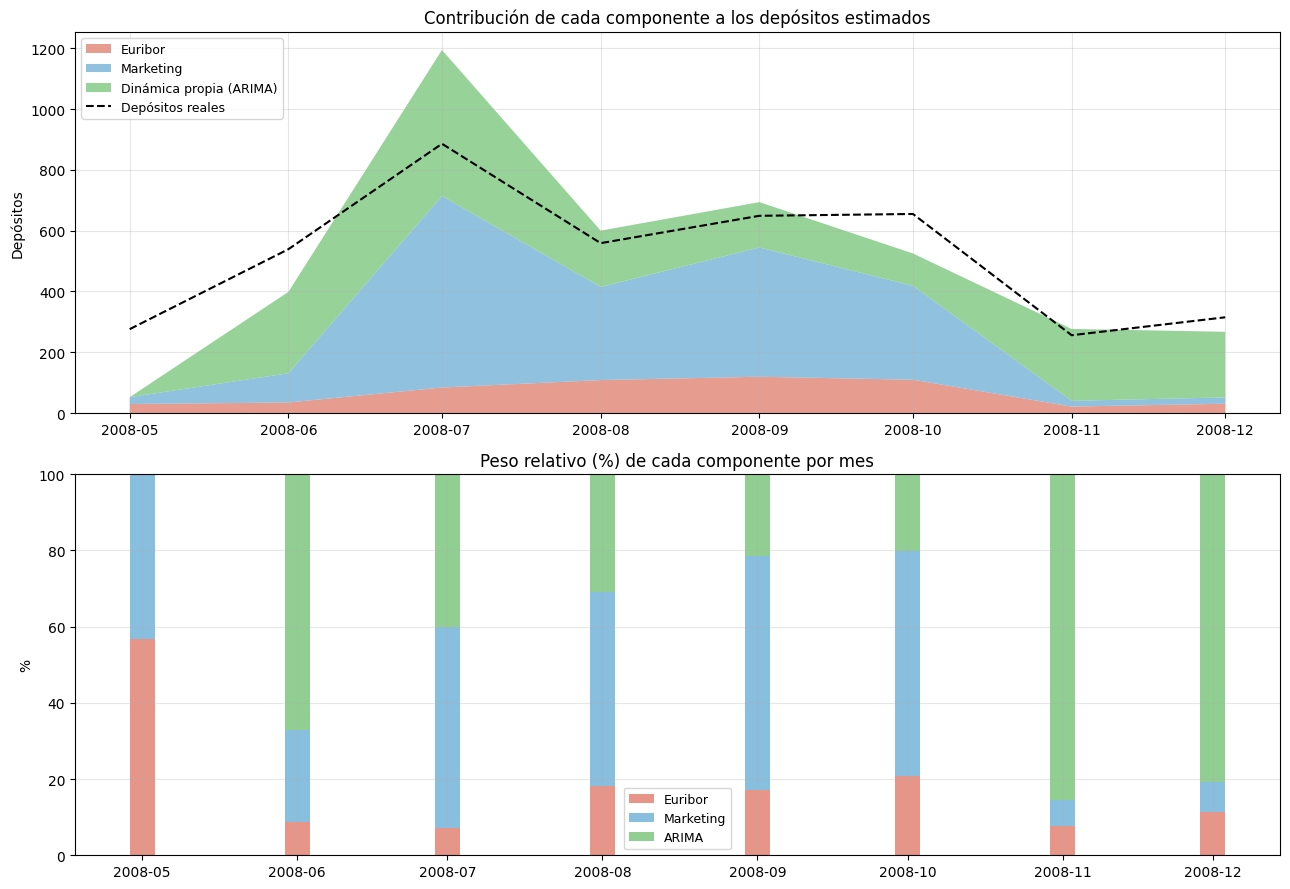

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# ── Panel 1: contribuciones apiladas ──────────────────────────
ax = axes[0]

ax.stackplot(contrib.index,
             contrib['euribor'],
             contrib['marketing'],
             contrib['parte_arima'],
             labels=['Euribor', 'Marketing', 'Dinámica propia (ARIMA)'],
             colors=['#e07b6b', '#6baed6', '#74c476'],
             alpha=0.75)

ax.plot(y_train.index, y_train,
        color='black', lw=1.5, linestyle='--', label='Depósitos reales')

ax.set_title('Contribución de cada componente a los depósitos estimados', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylabel('Depósitos')
ax.grid(True, alpha=0.3)

# ── Panel 2: contribución relativa (%) ────────────────────────
ax2 = axes[1]

total_abs = (contrib.abs().sum(axis=1))
pct = contrib.div(total_abs, axis=0) * 100

ax2.bar(pct.index, pct['euribor'],   label='Euribor',   color='#e07b6b', alpha=0.8, width=5)
ax2.bar(pct.index, pct['marketing'], label='Marketing', color='#6baed6', alpha=0.8,width=5,
        bottom=pct['euribor'])
ax2.bar(pct.index, pct['parte_arima'], label='ARIMA',   color='#74c476', alpha=0.8, width=5,
        bottom=pct['euribor'] + pct['marketing'])

ax2.set_title('Peso relativo (%) de cada componente por mes', fontsize=12)
ax2.set_ylabel('%')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
import os
print(os.getcwd())

C:\Users\tomas
